In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
WORK_DIR="/home/magnolia/DataScience/Stellar_Class"
TRAIN_PATH=Path(WORK_DIR,"data/train.csv")
TEST_PATH=Path(WORK_DIR, "data/test.csv")
MODEL_DIR=Path(WORK_DIR,"models")

In [3]:
df=pd.read_csv(TRAIN_PATH).set_index('id')
target=df['class']
df=df.drop('class', axis=1)
features=df.columns

In [4]:
df=df.drop(['alpha', 'delta', 'spectral_type', 'galaxy_population'], axis=1)

In [ ]:
# Random sample 1000 data points from original data
import random
from sklearn.model_selection import train_test_split

random.seed(10)
idx=random.sample(range(len(df)), 1000)

X=df.to_numpy()[idx]
y=target[idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=10)
X_train.shape, X_test.shape

((750, 6), (250, 6))

In [36]:
from sklearn.svm import SVC

SVCLF=SVC()
SVCLF.fit(X_train, y_train)
SVCLF.score(X_train, y_train), SVCLF.score(X_test, y_test)

(0.8666666666666667, 0.892)

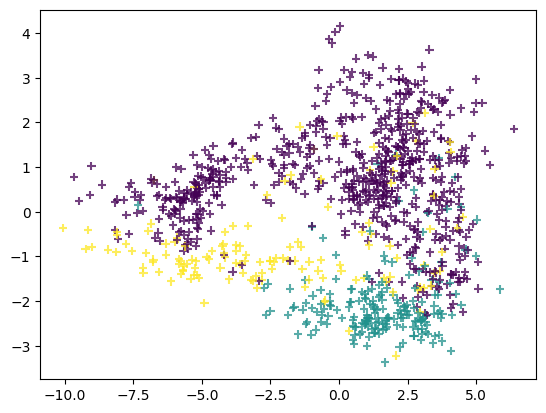

In [20]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
target_map={"GALAXY":0, "QSO":1, "STAR":2}
y_map=y.map(target_map)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_map, alpha=0.75, marker='+')

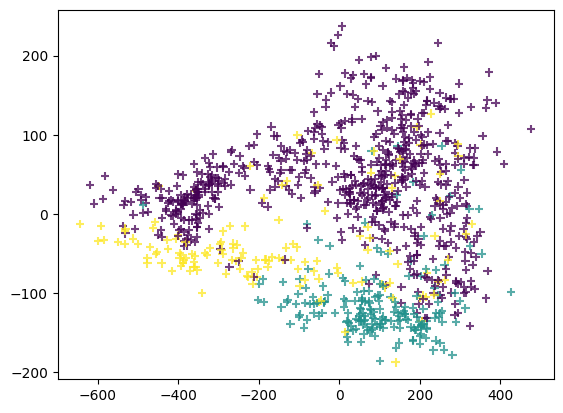

In [19]:
from sklearn.preprocessing import PolynomialFeatures
PF=PolynomialFeatures(degree=2)
X_pf=PF.fit_transform(X)
X_pf_pca=pca.fit_transform(X_pf)
plt.scatter(X_pf_pca[:,0], X_pf_pca[:,1], c=y_map, alpha=0.75, marker='+')

In [43]:
# Train SVC on Principal Components?
from sklearn.svm import SVC
SVClf=SVC()
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_map, random_state=10)
SVClf.fit(X_train, y_train)
print(f"Train R^2: {SVClf.score(X_train, y_train)}\nTest R^2: {SVClf.score(X_test, y_test)}")

Train R^2: 0.8666666666666667
Test R^2: 0.892


In [108]:
from sklearn.metrics import balanced_accuracy_score
y_pred=SVClf.predict(X_test)
print(f"Balanced Accuracy Score: {round(balanced_accuracy_score(y_test, y_pred), 2)}")

Balanced Accuracy Score: 0.78


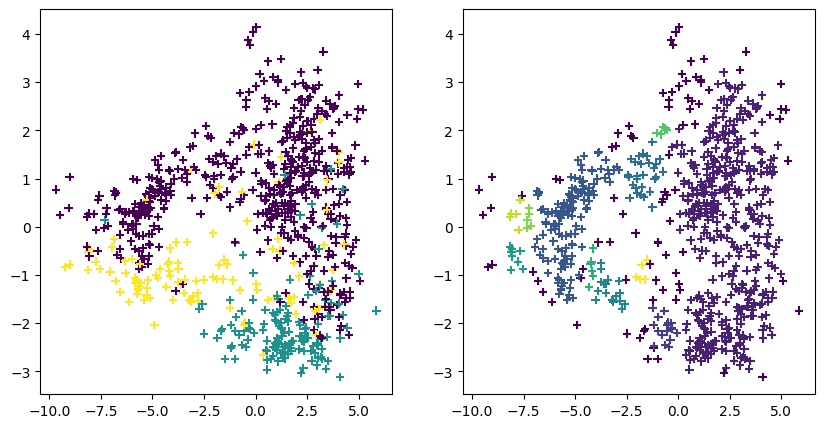

In [138]:
# Try DBSCAN?
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=0.4, min_samples=5)
y_pred=dbscan.fit_predict(X_train)

fig, axes= plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, marker='+')
axes[1].scatter(X_train[:,0], X_train[:,1], c=y_pred, marker='+')

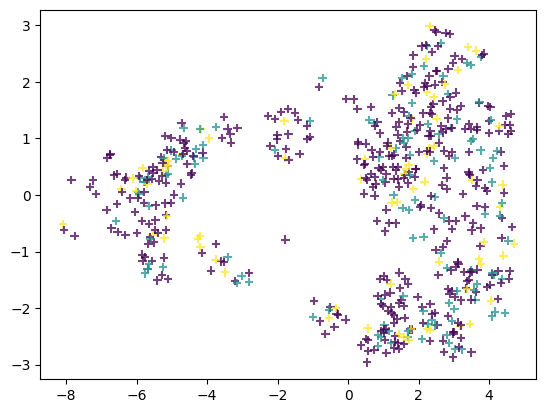

In [139]:
plt.scatter(dbscan.components_[:,0], dbscan.components_[:,1], 
            c=y_map.iloc[dbscan.core_sample_indices_], alpha=0.75, marker='+')

In [148]:
from sklearn.svm import LinearSVC

linear_svclf=LinearSVC()
linear_svclf.fit(X_train, y_train)
print(f"Train R^2: {linear_svclf.score(X_train, y_train)},\nTest R^2: {linear_svclf.score(X_test, y_test)}")

Train R^2: 0.8093333333333333,
Test R^2: 0.84
